# Post-Cavity Experiment Notebook

Comprehensive characterization using the **qubox_v2 v3** modular experiment API
with the unified `run() -> analyze() -> plot()` workflow.

**Sections:**
1. Initialization
2. OPX/Octave Mixer Calibration
3. Readout Characterization
4. Qubit Characterization
5. Pulse Calibration
6. Readout Calibration
7. SPA Benchmarking
8. Storage Cavity
9. Quantum State Tomography
10. Utility: Continuous-Wave Output

In [1]:
import sys
import numpy as np

sys.path.insert(0, r"E:\qubox")

from qualang_tools.units import unit

from qubox_v2.experiments.session import SessionManager
from qubox_v2.experiments import (
    # Spectroscopy
    ResonatorSpectroscopy,
    ResonatorPowerSpectroscopy,
    ResonatorSpectroscopyX180,
    ReadoutTrace,
    QubitSpectroscopy,
    QubitSpectroscopyEF,
    # Time domain
    PowerRabi,
    TemporalRabi,
    T1Relaxation,
    T2Ramsey,
    T2Echo,
    # Calibration
    IQBlob,
    ReadoutGEDiscrimination,
    ReadoutWeightsOptimization,
    ReadoutButterflyMeasurement,
    CalibrateReadoutFull,
    AllXY,
    DRAGCalibration,
    QubitPulseTrain,
    RandomizedBenchmarking,
    # Cavity / Fock
    StorageSpectroscopy,
    NumSplittingSpectroscopy,
    StorageChiRamsey,
    FockResolvedSpectroscopy,
    FockResolvedT1,
    FockResolvedRamsey,
    FockResolvedPowerRabi,
    # Tomography
    QubitStateTomography,
    StorageWignerTomography,
    SNAPOptimization,
    # SPA
    SPAFluxOptimization,
    SPAPumpFrequencyOptimization,
)
from qubox_v2.experiments.calibration import ReadoutConfig
from qubox_v2.calibration import CalibrationOrchestrator

u = unit()

2026-02-22 19:59:07,420 - qm - INFO     - Starting session: b7fd10d5-9c43-4352-a64f-677928a7a024


## 1. Initialization

Create a `SessionManager` which wires up hardware, pulses, calibration,
and device connections. All experiment classes accept it as their context.

In [2]:
experiment_path = r"E:\qubox\seq_1_device"

session = SessionManager(
    experiment_path,
    qop_ip="10.157.36.68",
    cluster_name="Cluster_2",
)

# Open QM connection and build element table (required before hardware ops)
session.open()

attr = session.attributes
print(f"Resonator: {attr.ro_fq / 1e9:.4f} GHz")
print(f"Qubit:     {attr.qb_fq / 1e9:.4f} GHz")
print(f"Storage:   {attr.st_fq / 1e9:.4f} GHz")

# Uncomment to run in simulation mode:
# session.hw.set_exec_mode("simulate")

[INFO] 2026-02-22 19:59:14,630 qubox.experiments.session: SessionManager initialising at E:\qubox\seq_1_device
2026-02-22 19:59:18,562 - qm - INFO     - Performing health check
2026-02-22 19:59:18,567 - qm - INFO     - Health check passed
[INFO] 2026-02-22 19:59:18,599 qubox.calibration.store: Loading calibration from E:\qubox\seq_1_device\config\calibration.json


Deprecated cqed_params keys loaded for backward compatibility: ['ro_therm_clks', 'qb_therm_clks', 'st_therm_clks', 'b_coherent_amp', 'b_coherent_len', 'b_alpha']


[INFO] 2026-02-22 19:59:22,560 qubox.experiments.session: SessionManager ready.
[INFO] 2026-02-22 19:59:23,845 qubox.experiments.session: Loaded measureMacro state from E:\qubox\seq_1_device\config\measureConfig.json
[INFO] 2026-02-22 19:59:23,846 qubox.experiments.session: Runtime element validation: available=['qubit', 'qubit2', 'resonator', 'storage']
Resonator: 8.5962 GHz
Qubit:     6.1504 GHz
Storage:   5.2409 GHz


### 1.0b Session Snapshot + Preflight + Readout Override

Unified setup block for reproducibility and runtime readout configuration.
This combined section replaces previous 1.0b, 1.1, and 1.2.

In [3]:
from pathlib import Path
from qubox_v2.core.session_state import SessionState
from qubox_v2.core.artifact_manager import ArtifactManager
from qubox_v2.core.preflight import preflight_check
from qubox_v2.core.artifacts import save_config_snapshot
from qubox_v2.core.schemas import validate_config_dir

# Orchestrator used by calibration preview/commit cells
orch = CalibrationOrchestrator(session)

config_dir = Path(experiment_path) / "config"
ss = SessionState.from_config_dir(config_dir)
am = ArtifactManager(experiment_path, ss.build_hash)
am.save_session_state(ss.to_dict())
print(ss.summary())
print(f"\nArtifacts root: {am.root}")

# Preflight validation
report = preflight_check(session)
if report["all_ok"]:
    print("All preflight checks PASSED.")
else:
    print("PREFLIGHT FAILURES:")
    for err in report["errors"]:
        print(f"  - {err}")

if report["warnings"]:
    print("Warnings:")
    for w in report["warnings"]:
        print(f"  - {w}")

snapshot_path = save_config_snapshot(session, tag="session_open")
print(f"\nConfig snapshot saved to: {snapshot_path}")

schema_results = validate_config_dir(config_dir)
print("\nSchema validation:")
for r in schema_results:
    status = "PASS" if r.valid else "FAIL"
    print(f"  {status} v={r.version}")
    for e in r.errors:
        print(f"    ERROR: {e}")
    for w in r.warnings:
        print(f"    WARN: {w}")

# Runtime readout override
READOUT_OVERRIDE_ELEMENT = attr.ro_el
READOUT_OVERRIDE_OP = "readout"
READOUT_OVERRIDE_WEIGHTS = None
READOUT_OVERRIDE_DEMOD = "dual_demod.full"
READOUT_OVERRIDE_THRESHOLD = None
READOUT_OVERRIDE_WEIGHT_LEN = None

override_info = session.override_readout_operation(
    element=READOUT_OVERRIDE_ELEMENT,
    operation=READOUT_OVERRIDE_OP,
    weights=READOUT_OVERRIDE_WEIGHTS,
    demod=READOUT_OVERRIDE_DEMOD,
    threshold=READOUT_OVERRIDE_THRESHOLD,
    weight_len=READOUT_OVERRIDE_WEIGHT_LEN,
    apply_to_attributes=True,
    persist_measure_config=True,
    drive_frequency=attr.ro_fq,
 )

print("\nRuntime readout override applied:")
print(f"  element:            {override_info['element']}")
print(f"  operation:          {override_info['operation']}")
print(f"  pulse:              {override_info['pulse']}")
print(f"  attributes.ro_el:   {override_info['attributes_ro_el']}")
print(f"  QM mapping:         {override_info['qm_config_entry']}")
print(f"  measureConfig path: {override_info['measure_config_path']}")

Schema warnings for hardware.json: File 'hardware.json' has no 'version' field, assuming v1; Element 'resonator' missing 'const' operation; Element 'resonator' missing 'zero' operation; Element 'qubit2' missing 'const' operation; Element 'qubit2' missing 'zero' operation; Element 'qubit' missing 'const' operation; Element 'qubit' missing 'zero' operation; Element 'storage' missing 'const' operation; Element 'storage' missing 'zero' operation
Schema validation failed for devices.json: Missing required top-level key 'devices'


SessionState (build_hash=f805bd32b3dc)
  timestamp: 2026-02-22T19:59:23.906704
  git_commit: 2cb066830ddb
  schemas:
    hardware: v1 (4307 bytes) — E:\qubox\seq_1_device\config\hardware.json
    calibration: v3.0.0 (2057 bytes) — E:\qubox\seq_1_device\config\calibration.json
    pulses: v2 (963208 bytes) — E:\qubox\seq_1_device\config\pulses.json
  hardware elements: ['resonator', 'qubit2', 'qubit', 'storage']
  calibration sections: ['discrimination', 'readout_quality', 'frequencies', 'coherence', 'pulse_calibrations']
  pulse specs: 1 definitions

Artifacts root: E:\qubox\seq_1_device\artifacts\f805bd32b3dc
All preflight checks PASSED.

Config snapshot saved to: E:\qubox\seq_1_device\artifacts\config_snapshot_session_open_20260222_195923.json

Schema validation:
  PASS v=1
    WARN: File 'hardware.json' has no 'version' field, assuming v1
    WARN: Element 'resonator' missing 'const' operation
    WARN: Element 'resonator' missing 'zero' operation
    WARN: Element 'qubit2' missing 

## 2. OPX/Octave Mixer Calibration

Calibrate IQ mixer offsets (DC offset, gain imbalance, phase imbalance) for
each element. Run this before any measurements to ensure clean signal generation.

### 2.0 Manual Calibration UX Controls

Configure logging, scan bounds/grid, SA settings, and sideband objective for manual IQ calibration.
These parameters are passed directly into `MixerCalibrationConfig`.

In [ ]:
# -------- Notebook-level UX toggles --------
QUIET_QM_LOGS = True      # suppress qm INFO compile/execute spam inside manual loops
LIVE_PLOTS = True         # live heatmaps/history while scanning/minimizing
LIVE_PLOT_EVERY = 1       # update cadence (iterations)

# -------- Scan bounds / grid --------
# Stage A (DC offset): coarse + fine 2D grid
DC_COARSE_RANGE = 0.10
DC_COARSE_N = 11
DC_FINE_RANGE = 0.02
DC_FINE_N = 11

# Stage B (IQ correction): coarse + fine 2D grid
IQ_GAIN_RANGE = 0.10
IQ_PHASE_RANGE = 0.20
IQ_COARSE_N = 11
IQ_FINE_GAIN_RANGE = 0.02
IQ_FINE_PHASE_RANGE = 0.04
IQ_FINE_N = 11

# Minimizer settings
MIN_MAXITER = 60
MIN_XTOL = 1e-4

# -------- Spectrum analyzer settings --------
SA_SPAN_HZ = 2e6
SA_RBW = 10e3
SA_VBW = 10e3
SA_LEVEL_DBM = 0.0
SA_AVG = 1
SA_SETTLE_S = 0.0

# Optional SA driver kwargs (only if your SA driver supports them)
# Examples: attenuation, detector, ref_level, preamp
SA_EXTRA_CONFIG = {
    # "attenuation": 10,
    # "detector": "peak",
}

# -------- Sideband targeting objective --------
# sideband='usb' means desired tone is LO+IF, image is LO-IF
# sideband='lsb' means desired tone is LO-IF, image is LO+IF
SIDEBAND = "lsb"
OBJECTIVE_MODE = "weighted_sum"   # 'weighted_sum' or 'ratio_db'
W_CARRIER = 1.0
W_IMAGE = 1.0
W_TARGET = 1.0

print("Manual calibration controls set.")

In [ ]:
hw = session.hw

# Gather elements and their frequencies
elements = [attr.ro_el, attr.qb_el, attr.st_el]
el_los = hw.get_element_lo(elements)
el_ifs = [hw.calculate_el_if_fq(el, fq)
          for el, fq in zip(elements, [attr.ro_fq, attr.qb_fq, attr.st_fq])]

print("Mixer calibration targets:")
for el, lo, if_fq in zip(elements, el_los, el_ifs):
    print(f"  {el:20s}  LO={lo/1e9:.4f} GHz  IF={if_fq/1e6:.2f} MHz")

# --- Manual IQ mixer calibration via SA124B (requires SA connected) ---
from qubox_v2.calibration import MixerCalibrationConfig, SAMeasurementHelper

cfg = MixerCalibrationConfig(
    # SA settings
    sa_span_hz=SA_SPAN_HZ,
    sa_rbw=SA_RBW,
    sa_vbw=SA_VBW,
    sa_level=SA_LEVEL_DBM,
    sa_avg=SA_AVG,
    sa_settle=SA_SETTLE_S,
    sa_extra_config=SA_EXTRA_CONFIG,

    # DC scan bounds/grid
    dc_coarse_range=DC_COARSE_RANGE,
    dc_coarse_n=DC_COARSE_N,
    dc_fine_range=DC_FINE_RANGE,
    dc_fine_n=DC_FINE_N,

    # IQ scan bounds/grid
    iq_gain_range=IQ_GAIN_RANGE,
    iq_phase_range=IQ_PHASE_RANGE,
    iq_coarse_n=IQ_COARSE_N,
    iq_fine_range_gain=IQ_FINE_GAIN_RANGE,
    iq_fine_range_phase=IQ_FINE_PHASE_RANGE,
    iq_fine_n=IQ_FINE_N,

    # Minimizer
    minimizer_maxiter=MIN_MAXITER,
    minimizer_xtol=MIN_XTOL,

    # UX controls
    quiet_qm_logs=QUIET_QM_LOGS,
    live_plot=LIVE_PLOTS,
    live_plot_every=LIVE_PLOT_EVERY,

    # Explicit sideband objective
    sideband=SIDEBAND,
    objective_mode=OBJECTIVE_MODE,
    w_carrier=W_CARRIER,
    w_image=W_IMAGE,
    w_target=W_TARGET,
)

target_el = "qubit"
idx = elements.index(target_el)
target_lo = float(el_los[idx])
target_if = float(el_ifs[idx])

# Baseline SA measurement before calibration
sa_dev = session.devices.get("sa124b")
sa_helper = SAMeasurementHelper(sa_dev, cfg)
before = sa_helper.measure_tones(target_lo, target_if)

# Run calibration (choose one method)
result = hw.calibrate_element(
    el=target_el,
    method="manual_minimizer",
    mixer_cal_config=cfg,
    save_to_db=False,
)

# Post-calibration SA measurement
after = sa_helper.measure_tones(target_lo, target_if)

print("\nManual calibration complete.")

# Quantitative mixer metrics summary
metrics_rows = [
    ("Target sideband power (dBm)", before["P_des_dBm"], after["P_des_dBm"], after["P_des_dBm"] - before["P_des_dBm"]),
    ("LO leakage power (dBm)", before["P_LO_dBm"], after["P_LO_dBm"], after["P_LO_dBm"] - before["P_LO_dBm"]),
    ("Image sideband power (dBm)", before["P_img_dBm"], after["P_img_dBm"], after["P_img_dBm"] - before["P_img_dBm"]),
    ("Target/LO (dBc)", before["LO_leak_dBc"], after["LO_leak_dBc"], after["LO_leak_dBc"] - before["LO_leak_dBc"]),
    ("Target/Image (dBc)", before["IRR_dBc"], after["IRR_dBc"], after["IRR_dBc"] - before["IRR_dBc"]),
]

print("\nMixer calibration metrics (before -> after):")
print(f"{'Metric':32s} {'Before':>10s} {'After':>10s} {'Delta':>10s}")
for name, b, a, d in metrics_rows:
    print(f"{name:32s} {b:10.2f} {a:10.2f} {d:10.2f}")

import matplotlib.pyplot as plt
labels = [r[0] for r in metrics_rows]
before_vals = [r[1] for r in metrics_rows]
after_vals = [r[2] for r in metrics_rows]

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, before_vals, width=w, label="Before")
ax.bar(x + w/2, after_vals, width=w, label="After")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_title("Mixer Calibration Metrics: Before vs After")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Readout Characterization

### 3.1 Readout Trace

Acquire raw ADC traces to verify readout signal level and timing.

In [ ]:
trace = ReadoutTrace(session)
result = trace.run(attr.ro_fq, n_avg=10000)

analysis = trace.analyze(result)
trace.plot(analysis)
print(analysis.metrics)

### 3.2 Resonator Spectroscopy

Sweep readout frequency to locate resonator resonance. The `analyze()` method
fits a Lorentzian and extracts `f0` and `kappa`.

In [ ]:
orch = CalibrationOrchestrator(session)
spec = ResonatorSpectroscopy(session)
res_cycle = orch.run_analysis_patch_cycle(
    spec,
    run_kwargs={
        "readout_op": "readout",
        "rf_begin": 8560 * u.MHz,
        "rf_end": 8640 * u.MHz,
        "df": 200 * u.kHz,
        "n_avg": 10000,
    },
    analyze_kwargs={"update_calibration": True},
    apply=False,
    persist_artifact=True,
 )

res_result = orch._run_result_from_artifact(res_cycle["artifact"])
res_analysis = spec.analyze(res_result, update_calibration=False)
spec.plot(res_analysis)
print(f"f0 = {res_cycle['calibration_result'].params.get('f0_MHz', float('nan')):.4f} MHz")
print(f"kappa = {res_cycle['calibration_result'].params.get('kappa', float('nan')) / 1e3:.1f} kHz")
print("Patch preview:")
for item in res_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(res_cycle["patch"], dry_run=False)

### 3.3 Resonator Power Spectroscopy

2D sweep of readout frequency vs gain to find optimal readout power.

In [ ]:
pspec = ResonatorPowerSpectroscopy(session)
result = pspec.run(
    "readout",
    rf_begin=8590 * u.MHz,
    rf_end=8600 * u.MHz,
    df=50 * u.kHz,
    g_min=0.01,
    g_max=1.9,
    N_a=20,
    n_avg=5000,
)

analysis = pspec.analyze(result)
pspec.plot(analysis)
print(f"Optimal gain: {analysis.metrics.get('optimal_gain', 'N/A')}")
print(f"Optimal freq: {analysis.metrics.get('optimal_freq', 'N/A')}")

### 3.4 Resonator Spectroscopy with X180

Measure resonator with ground and excited qubit states to extract
dispersive shift chi.

In [ ]:
spec_x180 = ResonatorSpectroscopyX180(session)
result = spec_x180.run(
    rf_begin=8560 * u.MHz,
    rf_end=8640 * u.MHz,
    df=200 * u.kHz,
    n_avg=10000,
)

analysis = spec_x180.analyze(result, update_calibration=True)
spec_x180.plot(analysis)
print(f"f0_g = {analysis.metrics.get('f0_g', 0) / 1e6:.4f} MHz")
print(f"f0_e = {analysis.metrics.get('f0_e', 0) / 1e6:.4f} MHz")
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")

## 4. Qubit Characterization

### 4.1 Qubit Spectroscopy

Sweep qubit drive frequency to locate the qubit transition.

In [ ]:

qb_spec = QubitSpectroscopy(session)
qb_cycle = orch.run_analysis_patch_cycle(
    qb_spec,
    run_kwargs={
        "pulse": "saturation",
        "rf_begin": 6130 * u.MHz,
        "rf_end": 6170 * u.MHz,
        "df": 500 * u.kHz,
        "qb_gain": 1.0,
        "qb_len": 1000,
        "n_avg": 1000,
    },
    analyze_kwargs={"update_calibration": True},
    apply=False,
    persist_artifact=True,
 )

qb_result = orch._run_result_from_artifact(qb_cycle["artifact"])
qb_analysis = qb_spec.analyze(qb_result, update_calibration=False)
qb_spec.plot(qb_analysis)
print(f"f0 = {qb_cycle['calibration_result'].params['f0_MHz']:.4f} MHz")
print("Patch preview:")
for item in qb_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(qb_cycle["patch"], dry_run=False)

### 4.2 Power Rabi

Sweep qubit drive amplitude to calibrate the pi pulse gain.

2026-02-22 19:59:24,105 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 19:59:24,185 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:30<00:00, 162.60it/s]

[INFO] 2026-02-22 19:59:54,985 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593056
No errors


[INFO] 2026-02-22 19:59:55,012 qubox.hardware.program_runner: Job halted successfully.


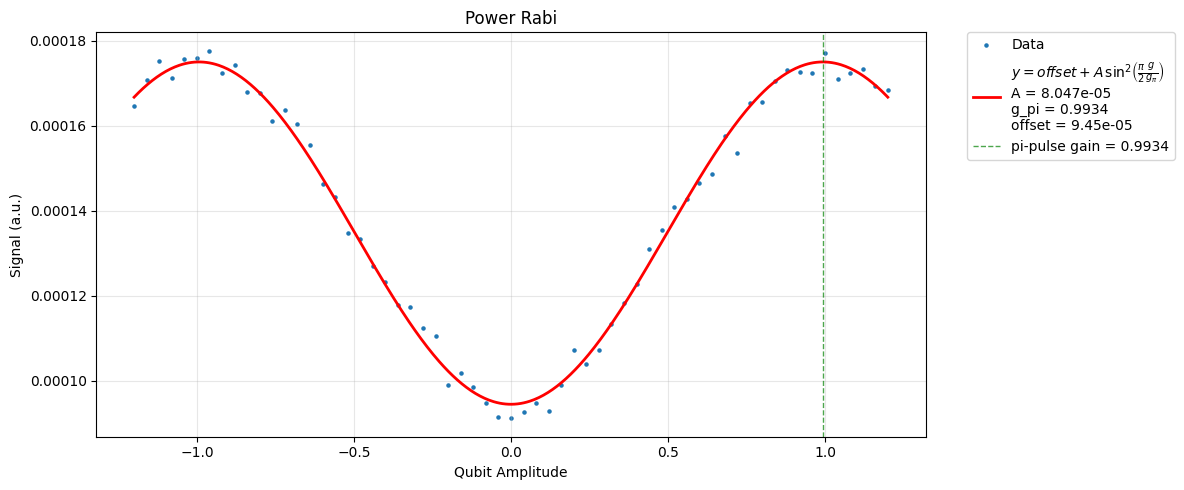

g_pi (ref_r180) = 0.993409
Patch preview:
  {'op': 'SetCalibration', 'payload': {'path': 'pulse_calibrations.ref_r180.amplitude', 'value': 0.11141324994152733}}
  {'op': 'SetPulseParam', 'payload': {'pulse_name': 'ref_r180', 'field': 'amplitude', 'value': 0.11141324994152733}}
  {'op': 'SetCalibration', 'payload': {'path': 'pulse_calibrations.x180.amplitude', 'value': 1.005833805015861}}
  {'op': 'SetPulseParam', 'payload': {'pulse_name': 'x180', 'field': 'amplitude', 'value': 1.005833805015861}}
  {'op': 'TriggerPulseRecompile', 'payload': {'include_volatile': True}}
  {'op': 'SetCalibration', 'payload': {'path': 'pulse_calibrations.ref_r180.amplitude', 'value': 0.9934090869770926}}
  {'op': 'TriggerPulseRecompile', 'payload': {'include_volatile': True}}


In [4]:
import importlib
import qubox_v2.calibration.orchestrator as orch_mod
importlib.reload(orch_mod)

orch = orch_mod.CalibrationOrchestrator(session)
rabi = PowerRabi(session)
rabi_cycle = orch.run_analysis_patch_cycle(
    rabi,
    run_kwargs={
        "max_gain": 1.2,
        "dg": 0.04,
        "op": "ref_r180",
        "n_avg": 5000,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [0.0001, 1, 0],
    },
    apply=False,
    persist_artifact=True,
 )

rabi_result = orch._run_result_from_artifact(rabi_cycle["artifact"])
rabi_analysis = rabi.analyze(rabi_result, update_calibration=False, p0=[0.0001, 1, 0])
rabi.plot(rabi_analysis)
rabi_g_pi = float(rabi_cycle["calibration_result"].params.get("g_pi", 1.0))
print(f"g_pi (ref_r180) = {rabi_g_pi:.6f}")
print("Patch preview:")
for item in rabi_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(rabi_cycle["patch"], dry_run=False)

### 4.3 Temporal Rabi

Sweep pulse duration at fixed amplitude to measure Rabi frequency.

In [ ]:
trabi = TemporalRabi(session)
result = trabi.run(
    pulse="const_x180",
    pulse_len_begin=16,
    pulse_len_end=500,
    dt=4,
    n_avg=5000,
)

analysis = trabi.analyze(result)
trabi.plot(analysis)
print(f"f_Rabi = {analysis.metrics.get('f_Rabi', 'N/A')} Hz")
print(f"pi_length = {analysis.metrics.get('pi_length', 'N/A')} ns")

### 4.4 T1 Relaxation

Measure energy relaxation time after a pi pulse.

2026-02-22 19:06:41,617 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 19:06:41,692 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 1999/2000 [00:25<00:00, 79.60it/s]

[INFO] 2026-02-22 19:07:06,867 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593052
No errors
[INFO] 2026-02-22 19:07:06,892 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 19:07:06,895 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\T1Relaxation_20260222_190706.npz
[INFO] 2026-02-22 19:07:06,899 qubox.experiments.experiment_base: Calibration commit applied for t1_relaxation. Artifact saved at E:\qubox\seq_1_device\artifacts\calibration_runs\t1_relaxation_20260222_190706.json


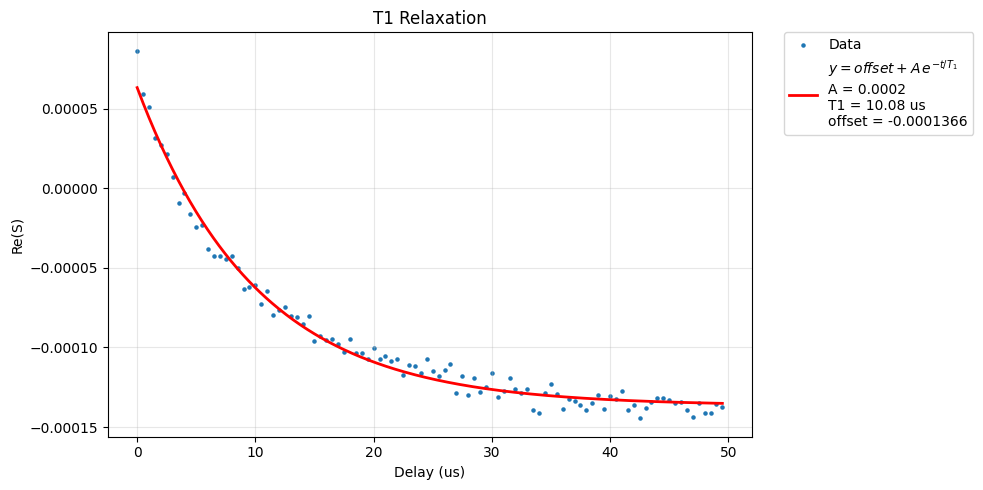

T1 = 10.08 us


In [ ]:
t1 = T1Relaxation(session)
t1_cycle = orch.run_analysis_patch_cycle(
    t1,
    run_kwargs={
        "delay_end": 50 * u.us,
        "dt": 500,
        "n_avg": 2000,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [0, 10, 0],
        "p0_time_unit": "us",
        "derive_qb_therm_clks": True,
        "clock_period_ns": 4.0,
    },
    apply=False,
    persist_artifact=True,
 )

t1_result = orch._run_result_from_artifact(t1_cycle["artifact"])
t1_analysis = t1.analyze(t1_result, update_calibration=False, p0=[0, 10, 0], p0_time_unit="us")
t1.plot(t1_analysis)
print(f"T1 = {t1_cycle['calibration_result'].params.get('T1_us', float('nan')):.2f} us")
print(f"qb_therm_clks (proposed) = {t1_cycle['calibration_result'].params.get('qb_therm_clks', 'N/A')}")
print("Patch preview:")
for item in t1_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(t1_cycle["patch"], dry_run=False)

### 4.5 T2 Ramsey

Ramsey interferometry with intentional detuning to measure T2*.

2026-02-22 19:07:07,316 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 19:07:07,377 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 3999/4000 [03:12<00:00, 20.74it/s]

[INFO] 2026-02-22 19:10:20,251 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593053
No errors


[INFO] 2026-02-22 19:10:20,281 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 19:10:20,284 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\T2Ramsey_20260222_191020.npz
[INFO] 2026-02-22 19:10:20,294 qubox.experiments.experiment_base: Calibration commit applied for t2_ramsey. Artifact saved at E:\qubox\seq_1_device\artifacts\calibration_runs\t2_ramsey_20260222_191020.json


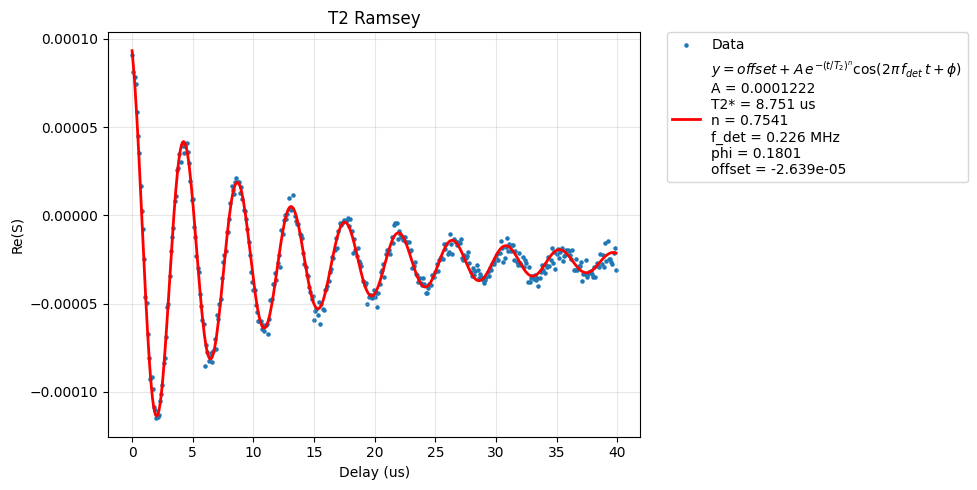

T2* = 8.75 us
f_det = 0.2260 MHz


In [ ]:
t2r = T2Ramsey(session)
qb_det_MHz = 0.2
t2r_cycle = orch.run_analysis_patch_cycle(
    t2r,
    run_kwargs={
        "qb_detune": int(qb_det_MHz * 1e6),
        "delay_end": 40 * u.us,
        "dt": 100,
        "n_avg": 4000,
        "qb_detune_MHz": qb_det_MHz,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [0, 20, 1.0, qb_det_MHz, 0.0, 0],
        "p0_time_unit": "us",
        "p0_freq_unit": "MHz",
        "apply_frequency_correction": False,
        "freq_correction_sign": -1.0,
    },
    apply=False,
    persist_artifact=True,
 )

t2r_result = orch._run_result_from_artifact(t2r_cycle["artifact"])
t2r_analysis = t2r.analyze(
    t2r_result,
    update_calibration=False,
    p0=[0, 20, 1.0, qb_det_MHz, 0.0, 0],
    p0_time_unit="us",
    p0_freq_unit="MHz",
 )
t2r.plot(t2r_analysis)
print(f"T2* = {t2r_cycle['calibration_result'].params.get('T2_star_us', float('nan')):.2f} us")
print(f"f_det = {t2r_cycle['calibration_result'].params.get('f_det_MHz', float('nan')):.4f} MHz")
print("Patch preview:")
for item in t2r_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(t2r_cycle["patch"], dry_run=False)

### 4.6 T2 Echo

Hahn echo measurement for T2_echo (removing low-frequency dephasing).

2026-02-22 19:10:20,649 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 19:10:20,715 - qm - INFO     - Executing program


E:\qubox\qubox_v2\experiments\time_domain\coherence.py:178: RuntimeWarning: dt 100 rounded to 96 (grid=8)
  half_wait_clks = create_clks_array(delay_begin, delay_end, dt, time_per_clk=8)
Running Program...: 100%|█████████▉| 3999/4000 [03:21<00:00, 19.89it/s]

[INFO] 2026-02-22 19:13:41,852 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593054
No errors


[INFO] 2026-02-22 19:13:41,879 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 19:13:41,883 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\T2Echo_20260222_191341.npz
[INFO] 2026-02-22 19:13:41,889 qubox.experiments.experiment_base: Calibration commit applied for t2_echo. Artifact saved at E:\qubox\seq_1_device\artifacts\calibration_runs\t2_echo_20260222_191341.json


E:\qubox\qubox_v2\analysis\cQED_models.py:489: RuntimeWarning: invalid value encountered in power
  return offset + A * np.exp(-(t / T2_echo)**n)


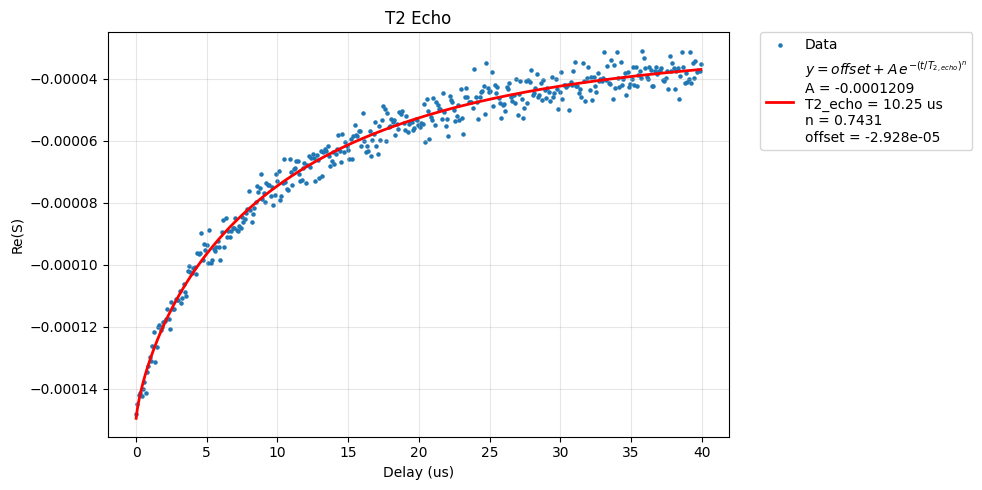

T2_echo = 10.25 us


In [ ]:
t2e = T2Echo(session)
t2e_cycle = orch.run_analysis_patch_cycle(
    t2e,
    run_kwargs={
        "delay_end": 40 * u.us,
        "dt": 100,
        "n_avg": 4000,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [-1, 40, 1.0, 0],
        "p0_time_unit": "us",
    },
    apply=False,
    persist_artifact=True,
 )

t2e_result = orch._run_result_from_artifact(t2e_cycle["artifact"])
t2e_analysis = t2e.analyze(t2e_result, update_calibration=False, p0=[-1, 40, 1.0, 0], p0_time_unit="us")
t2e.plot(t2e_analysis)
print(f"T2_echo = {t2e_cycle['calibration_result'].params.get('T2_echo_us', float('nan')):.2f} us")
print("Patch preview:")
for item in t2e_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(t2e_cycle["patch"], dry_run=False)

### 4.7 Primitive Pulse Waveform Update

Apply the Power Rabi calibration (`g_pi`) to the reference pulse and regenerate
all qubit rotation waveforms. The flow:

1. Retrieve `ref_r180` reference attributes (amplitude, length=16 ns, sigma=length/6, drag_coeff=0)
2. Scale the stored reference amplitude by `g_pi` from Power Rabi
3. Generate DRAG Gaussian I/Q waveforms at the calibrated amplitude
4. Call `register_rotations_from_ref_iq()` to derive all standard gates
   (x180, x90, y180, y90, etc.) from the reference, then push to QM config

In [ ]:
# Commit PowerRabi patch after manual preview approval
print("PowerRabi patch preview:")
for item in rabi_cycle["dry_run"]["preview"]:
    print(" ", item)

# Uncomment to commit the previewed patch:
# rabi_apply = orch.apply_patch(rabi_cycle["patch"], dry_run=False)
# print(rabi_apply)

primitive_ops = ["x180", "y180", "x90", "xn90", "y90", "yn90"]
primitive_amps = {}
for op_name in primitive_ops:
    pcal = session.calibration.get_pulse_calibration(op_name)
    primitive_amps[op_name] = getattr(pcal, "amplitude", None)

print("Primitive amplitudes (current store):")
for op_name in primitive_ops:
    print(f"  {op_name:5s} -> {primitive_amps[op_name]}")

ref_r180 base amplitude = 0.112152
g_pi (fitted)          = 1.000000
updated ref_r180 amp   = 0.112152
[INFO] 2026-02-22 18:47:00,263 qubox.experiments.session: Saved pulse manager state to E:\qubox\seq_1_device\config\pulses.json
[INFO] 2026-02-22 18:47:00,266 qubox.calibration.store: Calibration saved to E:\qubox\seq_1_device\config\calibration.json

Saved pulses to: E:\qubox\seq_1_device\config\pulses.json
Primitive amplitudes:
  x180  -> 1.012507151587043
  y180  -> None
  x90   -> None
  xn90  -> None
  y90   -> None
  yn90  -> None


## 5. Pulse Calibration

### 5.1 DRAG Calibration

Sweep DRAG coefficient to minimize leakage to the second excited state.

2026-02-22 18:42:40,910 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:42:41,008 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:20<00:00, 247.39it/s]

[INFO] 2026-02-22 18:43:01,278 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593046
No errors
[INFO] 2026-02-22 18:43:01,320 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:43:01,324 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\dragCalibration_20260222_184301.npz
[INFO] 2026-02-22 18:43:01,325 qubox.experiments.experiment_base: Calibration commit applied for drag_calibration_x180. Artifact saved at E:\qubox\seq_1_device\artifacts\calibration_runs\drag_calibration_x180_20260222_184301.json


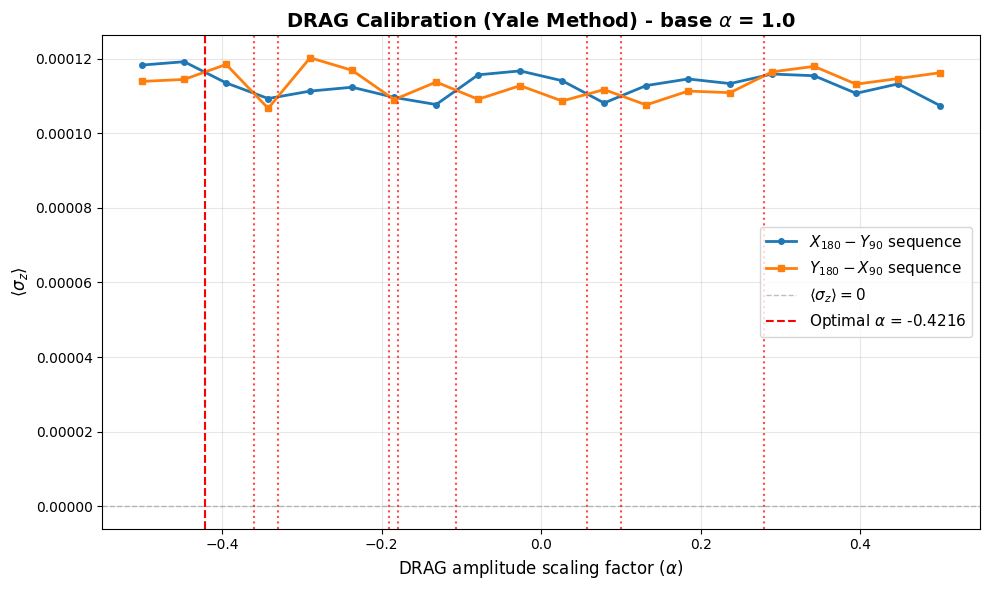

Optimal alpha = -0.42164679327966453
Stored ref_r180.drag_coeff = -0.42164679327966453
Stored x180.drag_coeff     = -0.42164679327966453


In [ ]:
drag = DRAGCalibration(session)
drag_cycle = orch.run_analysis_patch_cycle(
    drag,
    run_kwargs={
        "amps": np.linspace(-0.5, 0.5, 20),
        "n_avg": 5000,
        "base_alpha": 1.0,
    },
    analyze_kwargs={
        "update_calibration": True,
        "propagate_drag_to_primitives": True,
    },
    apply=False,
    persist_artifact=True,
 )

drag_result = orch._run_result_from_artifact(drag_cycle["artifact"])
drag_analysis = drag.analyze(drag_result, update_calibration=False)
drag.plot(drag_analysis)
print(f"Optimal alpha = {drag_cycle['calibration_result'].params.get('optimal_alpha', 'N/A')}")
print("Patch preview:")
for item in drag_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after quality review:
# orch.apply_patch(drag_cycle["patch"], dry_run=False)

### 5.1b DRAG Calibration Commit

Wrap the DRAG calibration result in a `CalibrationStateMachine` lifecycle
and commit via `CalibrationPatch` if the fit quality passes validation.

In [ ]:
from qubox_v2.calibration.state_machine import (
    CalibrationStateMachine, CalibrationState,
    CalibrationPatch, PatchValidation,
)

sm_drag = CalibrationStateMachine(experiment="drag_calibration")
sm_drag.transition(CalibrationState.CONFIGURED)
sm_drag.transition(CalibrationState.ACQUIRING)
sm_drag.transition(CalibrationState.ACQUIRED)
sm_drag.transition(CalibrationState.ANALYZING)

optimal_alpha = analysis.metrics.get("optimal_alpha", None)

# Retrieve current DRAG coefficient
drag_cal = session.calibration.get_pulse_calibration("ref_r180")
old_drag = drag_cal.drag_coeff if (drag_cal and drag_cal.drag_coeff is not None) else 0.0

# Build patch
drag_patch = CalibrationPatch(experiment="drag_calibration")
drag_patch.add_change(
    path="pulse_calibrations.ref_r180.drag_coeff",
    old_value=float(old_drag),
    new_value=float(optimal_alpha) if optimal_alpha is not None else None,
)

alpha_valid = optimal_alpha is not None and np.isfinite(optimal_alpha)
bounds_ok = alpha_valid and abs(optimal_alpha) < 5.0

drag_patch.validation = PatchValidation(
    passed=alpha_valid and bounds_ok,
    checks={"alpha_finite": alpha_valid, "alpha_bounds": bounds_ok},
    reasons=[] if (alpha_valid and bounds_ok) else
            [f"optimal_alpha={optimal_alpha} out of range or invalid"],
)
drag_patch.metadata = {"optimal_alpha": optimal_alpha}
sm_drag.patch = drag_patch

sm_drag.transition(CalibrationState.ANALYZED)
sm_drag.transition(CalibrationState.PENDING_APPROVAL)

print(drag_patch.summary())

if drag_patch.is_approved():
    sm_drag.transition(CalibrationState.COMMITTING)
    # DRAG coefficient is already committed by analyze(update_calibration=True)
    # above â€” this records the patch artifact for audit
    sm_drag.transition(CalibrationState.COMMITTED)
    print(f"\nDRAG commit recorded: alpha = {optimal_alpha:.4f}")
    am.save_artifact("drag_calibration_patch", drag_patch.to_dict())
else:
    am.save_artifact("drag_calibration_candidate", drag_patch.to_dict())
    print("\nDRAG calibration NOT committed. Candidate saved as artifact.")

### 5.2 Qubit Pulse Train

Repeated gate applications to measure amplitude and phase errors.

In [ ]:
ptrain = QubitPulseTrain(session)
result = ptrain.run(
    N_values=list(range(1, 51)),
    rotation_pulse="x180",
    n_avg=5000,
)

analysis = ptrain.analyze(result)
ptrain.plot(analysis)
print(analysis.metrics)

### 5.3 AllXY

21-point gate error diagnostic. Ideal result is the stepped staircase pattern.

2026-02-22 18:42:04,467 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:42:05,251 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:10<00:00, 470.11it/s]

[INFO] 2026-02-22 18:42:15,952 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593044
No errors


[INFO] 2026-02-22 18:42:15,986 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:42:15,990 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\allXY_20260222_184215.npz


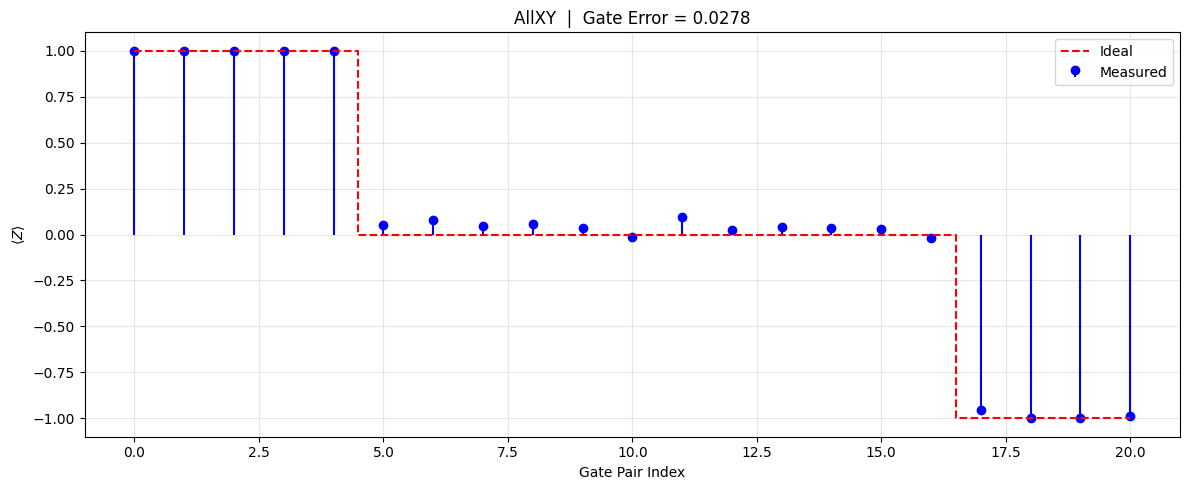

Gate error = 0.0278
Observable = sigma_z
State map  = {'g': 1.0, 'e': -1.0}
Confusion correction used = True
Confusion matrix present  = True


In [3]:
from qubox_v2.programs.macros.measure import measureMacro

allxy = AllXY(session)
result = allxy.run(n_avg=5000)
analysis = allxy.analyze(result)
allxy.plot(analysis)

print(f"Gate error = {analysis.metrics.get('gate_error', float('nan')):.4f}")
print(f"Observable = {analysis.metrics.get('observable', 'unknown')}")
print(f"State map  = {analysis.metrics.get('state_mapping', {})}")
print(f"Confusion correction used = {analysis.metrics.get('used_confusion_correction', False)}")
print(f"Confusion matrix present  = {measureMacro._ro_quality_params.get('confusion_matrix') is not None}")

In [ ]:
from qubox_v2. programs.macros.measure import measureMacro
confusion = measureMacro._ro_quality_params.get("confusion_matrix", None)
confusion

### 5.4 Randomized Benchmarking

Single-qubit Clifford RB for average gate fidelity.

In [ ]:
rb = RandomizedBenchmarking(session)
result = rb.run(
    m_list=[1, 5, 10, 20, 50, 100, 200],
    num_sequence=20,
    n_avg=1000,
)

# p0: [p, A, B]  -- p ~ 0.99 typical
analysis = rb.analyze(result, p0=[0.99, 0.5, 0.5])
rb.plot(analysis)
print(f"p = {analysis.metrics.get('p', 'N/A')}")
print(f"Avg gate fidelity = {analysis.metrics.get('avg_gate_fidelity', 'N/A')}")
print(f"Error per gate = {analysis.metrics.get('error_per_gate', 'N/A')}")

## 6. Readout Calibration

### 6.1 IQ Blob

Acquire IQ blobs for ground and excited states.

2026-02-22 18:42:29,431 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:42:29,496 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:01<00:00, 4569.82it/s]

[INFO] 2026-02-22 18:42:30,650 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593045
No errors
[INFO] 2026-02-22 18:42:30,700 qubox.hardware.program_runner: Job halted successfully.


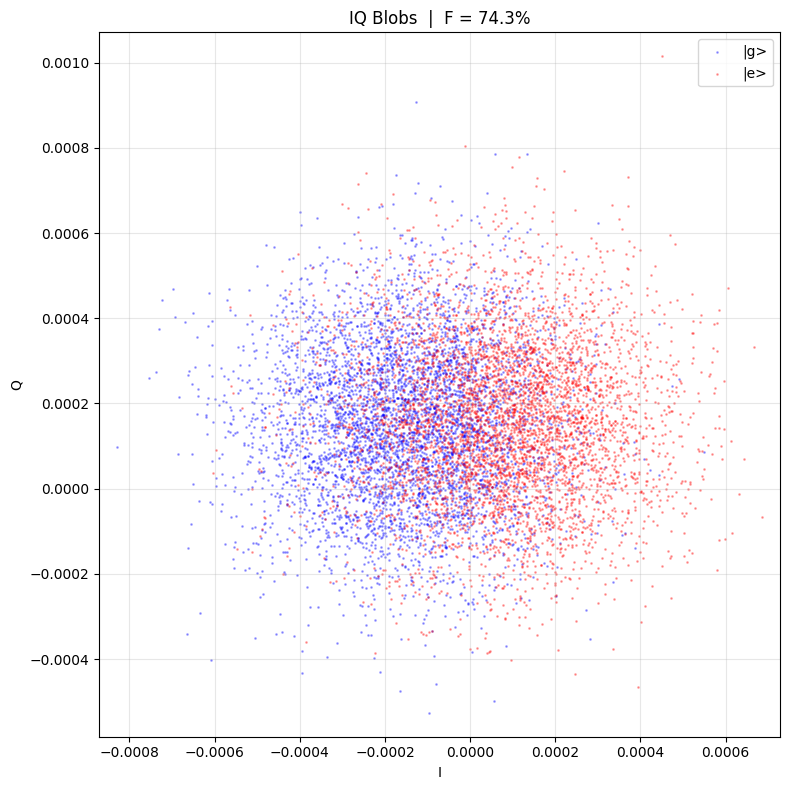

Readout fidelity = 7433.00%


In [4]:
iq = IQBlob(session)
result = iq.run("x180", n_runs=5000)

analysis = iq.analyze(result)
iq.plot(analysis)
print(f"Readout fidelity = {analysis.metrics.get('fidelity', 0):.2%}")

### 6.2 Standalone Readout Weight Optimization

Optimize integration weights using time-sliced g/e readout traces.
Computes the normalised `e - g` difference trace, builds segmented
integration weights (cos/sin/minus_sin triplet), and registers them
in the PulseOperationManager.

This is the same experiment run inside `CalibrateReadoutFull` Step 1,
exposed here for standalone use and debugging.

In [ ]:
wopt = ReadoutWeightsOptimization(session)
result = wopt.run(
    ro_op="readout",
    drive_frequency=attr.ro_fq,
    cos_w_key="cos",
    sin_w_key="sin",
    m_sin_w_key="minus_sin",
    num_div=1,
    r180="x180",
    n_avg=200_000,
    persist=True,
    set_measure_macro=True,
)

analysis = wopt.analyze(result)
wopt.plot(analysis)

print(f"trace_length     = {analysis.metrics.get('trace_length', 'N/A')}")
print(f"ge_diff_norm_max = {analysis.metrics.get('ge_diff_norm_max', 'N/A'):.4f}")
print(f"opt_cos_key      = {analysis.metrics.get('opt_cos_key', 'N/A')}")
print(f"opt_sin_key      = {analysis.metrics.get('opt_sin_key', 'N/A')}")
print(f"opt_m_sin_key    = {analysis.metrics.get('opt_m_sin_key', 'N/A')}")

### 6.3 GE Discrimination

Full discrimination analysis with optimal angle, threshold, and confusion matrix.

[INFO] 2026-02-22 18:01:20,510 qubox.experiments.calibration.readout: GE discrimination: n_samples=50000, measure_op='readout'


[INFO] 2026-02-22 18:01:20,543 qubox.experiments.calibration.readout: GE discrimination mapping: element=resonator op=readout pulse=readout_pulse available_ops=['const', 'readout']
2026-02-22 18:01:20,680 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:01:20,746 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:10<00:00, 4946.61it/s]

[INFO] 2026-02-22 18:01:30,911 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593019
No errors


[INFO] 2026-02-22 18:01:30,987 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:01:32,718 qubox.experiments.calibration.readout: GE discrimination fidelity=74.20%, angle=1.2434 rad, threshold=-2.947e-05
[INFO] 2026-02-22 18:01:34,148 qubox.experiments.calibration.readout: measureMacro updated with rotated readout weights
[INFO] 2026-02-22 18:01:34,151 qubox.experiments.calibration.readout: Persisted measureMacro state to E:\qubox\seq_1_device\config\measureConfig.json
[INFO] 2026-02-22 18:01:34,151 qubox.experiments.calibration.readout: Rotated integration weights computed AND applied
[INFO] 2026-02-22 18:01:34,152 qubox.experiments.calibration.readout: Rotated weight verification: PASSED. Active weights: {'rot_cos': 'rot_cos', 'rot_sin': 'rot_sin', 'rot_m_sin': 'rot_m_sin'}
[INFO] 2026-02-22 18:01:34,152 qubox.experiments.calibration.readout: Rotated weights validation PASSED
[INFO] 2026-02-22 18:01:34,153 qubox.experiments.calibration.readout: Post-selecti

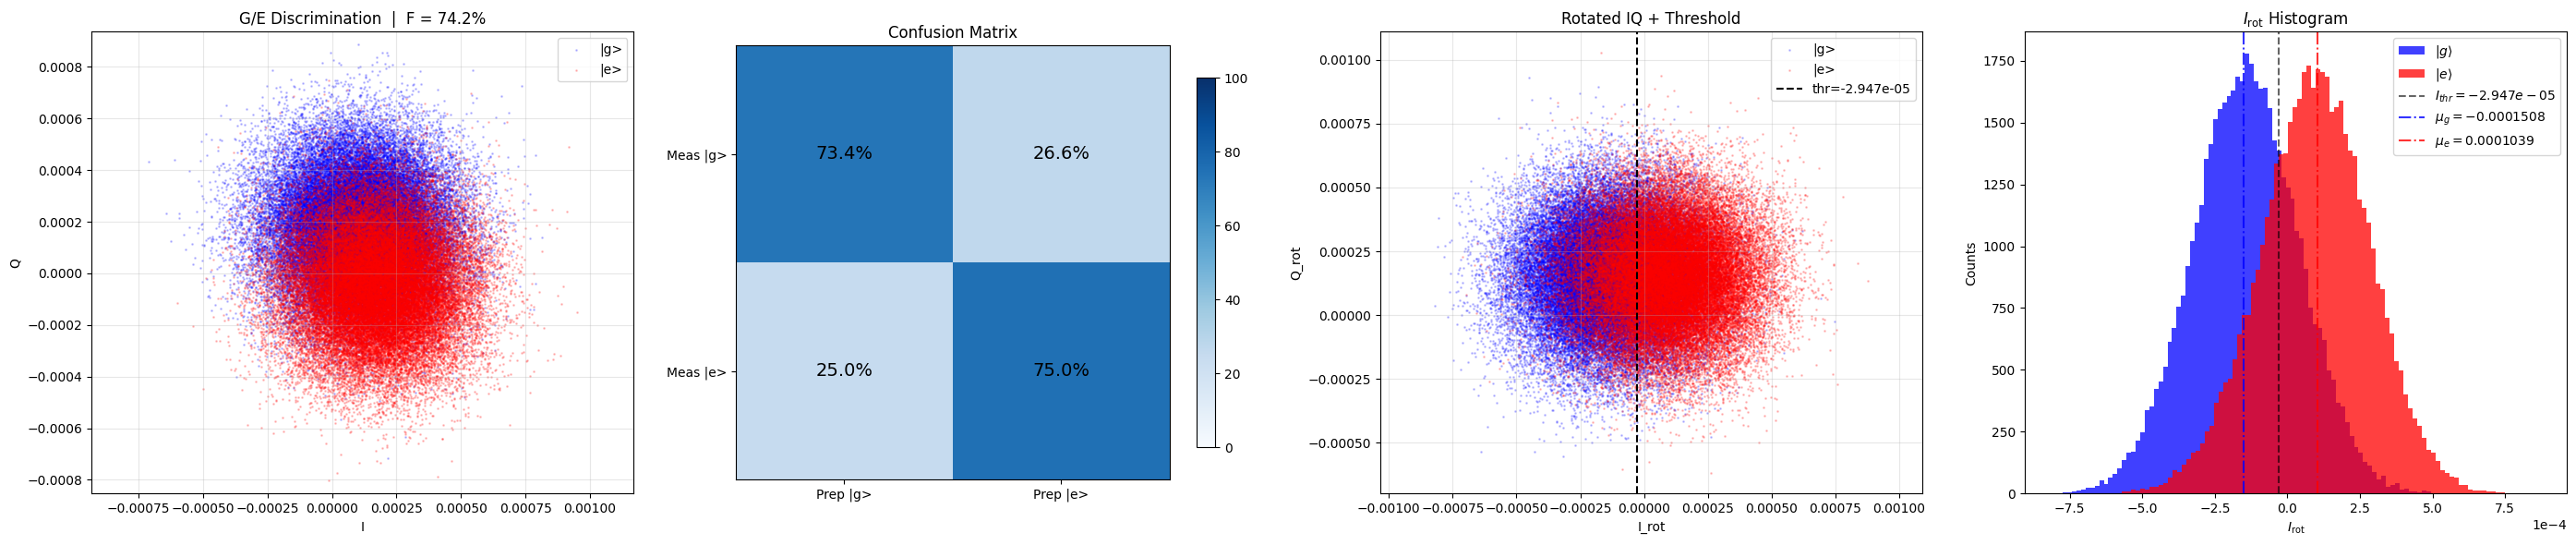

Fidelity = 7420.20%
Angle = 1.243 rad
Threshold = -0.0000

Resolved readout_ge mapping:
  element_readout: resonator
  operation:       readout
  pulse key:       readout_pulse
  base weights:    cos=readout_cosine_weights, sin=readout_sine_weights, m_sin=readout_minus_weights
Gaussianity (g) = 0.054
Gaussianity (e) = 0.191


In [ ]:
from qubox_v2.experiments.calibration.readout import ReadoutGEDiscrimination

ge = ReadoutGEDiscrimination(session)
result = ge.run(
    "readout",
    attr.ro_fq,
    r180="x180",
    n_samples=50000,
    update_measure_macro=True,
    apply_rotated_weights=True,
    persist=True,
)

analysis = ge.analyze(result, update_calibration=True)
ge.plot(analysis, show_rotated=True, interactive=False)
print(f"Fidelity = {analysis.metrics.get('fidelity', 0):.2f}%")
print(f"Angle = {analysis.metrics.get('angle', 0):.3f} rad")
print(f"Threshold = {analysis.metrics.get('threshold', 0):.4f}")

# Explicit mapping diagnostics
rp = getattr(ge, "_run_params", {})
print("\nResolved readout_ge mapping:")
print(f"  element_readout: {attr.ro_el}")
print(f"  operation:       {rp.get('measure_op')}")
print(f"  pulse key:       {getattr(rp.get('pulse_info', None), 'pulse', None)}")
print(f"  base weights:    cos={rp.get('base_cos_name')}, sin={rp.get('base_sin_name')}, m_sin={rp.get('base_m_sin_name')}")

# New diagnostics from the enhanced pipeline
if "gaussianity_g" in analysis.metrics:
    print(f"Gaussianity (g) = {analysis.metrics['gaussianity_g']:.3f}")
    print(f"Gaussianity (e) = {analysis.metrics['gaussianity_e']:.3f}")
if "cv_fidelity" in analysis.metrics:
    print(f"Cross-validated fidelity = {analysis.metrics['cv_fidelity']:.2%}")

### 6.4 Butterfly Measurement

Two successive measurements to quantify QND fidelity, F, Q, and V.

[INFO] 2026-02-22 17:56:56,973 qubox.experiments.calibration.readout: Butterfly measureMacro sync applied: element=resonator op=readout weights=['rot_cos', 'rot_sin', 'rot_m_sin']
[INFO] 2026-02-22 17:56:56,974 qubox.experiments.calibration.readout: Butterfly measurement: n_samples=50000, policy='BLOBS'
2026-02-22 17:56:57,159 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 17:56:57,711 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:03<00:00, 16333.48it/s]

[INFO] 2026-02-22 17:57:00,881 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593016
No errors


[INFO] 2026-02-22 17:57:01,195 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 17:57:01,198 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\butterflyMeasurement_20260222_175701.npz
[INFO] 2026-02-22 17:57:01,203 qubox.experiments.calibration.readout: Butterfly metrics: F=0.7182, Q=0.9729, V=0.4363, t01=0.0023, t10=0.0518
[WARNING] 2026-02-22 17:57:01,207 qubox.experiments.experiment_base: Calibration commit skipped for readout_butterfly. Artifact saved at E:\qubox\seq_1_device\artifacts\calibration_runs\readout_butterfly_20260222_175701.json. Errors: ['No fit object available']
[INFO] 2026-02-22 17:57:01,207 qubox.experiments.calibration.readout: measureMacro readout quality updated from butterfly analysis
[INFO] 2026-02-22 17:57:01,208 qubox.experiments.calibration.readout: T1 decay correction: readout=1600 ns, T1=19054941739.3 us, factor=1.0000
F = 71.82%
Q = 97.29%
V = 0.4363
t01 = 0.0023
t10 = 0.0518
Lambda_M_valid = True


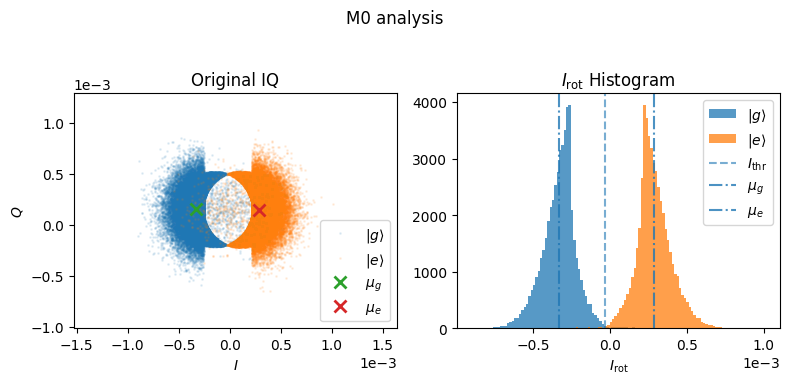

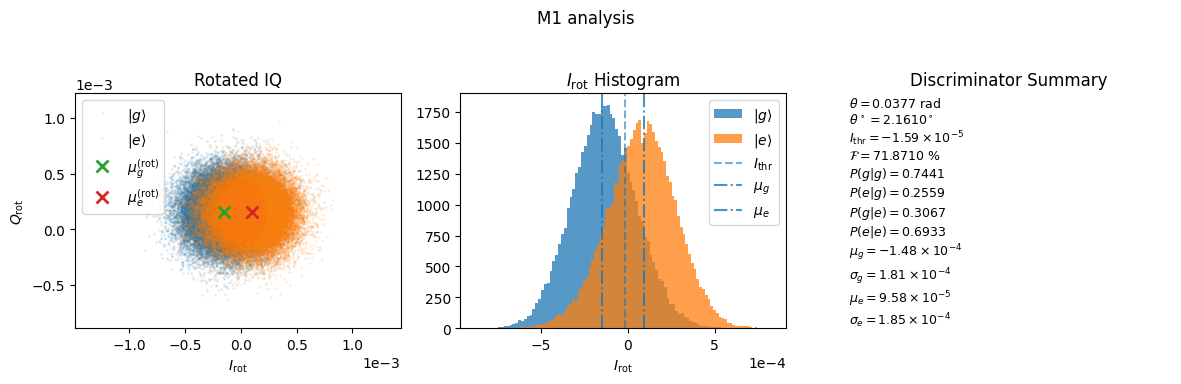

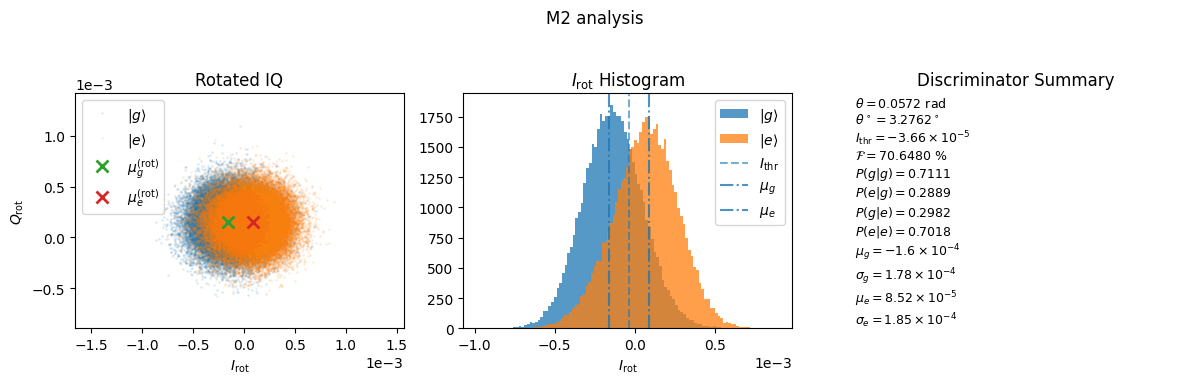

In [6]:
from qubox_v2.experiments.calibration.readout import ReadoutButterflyMeasurement

bfly = ReadoutButterflyMeasurement(session)
result = bfly.run(r180="x180", update_measure_macro=True, n_samples=50000)

analysis = bfly.analyze(result, update_calibration=True)
bfly.plot(analysis, show_histogram=True, show_discriminator=True)
print(f"F = {analysis.metrics.get('F', 0):.2%}")
print(f"Q = {analysis.metrics.get('Q', 0):.2%}")
print(f"V = {analysis.metrics.get('V', 0):.4f}")

# New diagnostics from the enhanced pipeline
if "t01" in analysis.metrics:
    print(f"t01 = {analysis.metrics['t01']:.4f}")
    print(f"t10 = {analysis.metrics['t10']:.4f}")
if "Lambda_M_valid" in analysis.metrics:
    print(f"Lambda_M_valid = {analysis.metrics['Lambda_M_valid']}")

### 6.5 Full Readout Calibration Pipeline

Run the full state machine pipeline with explicit staged patch review and commit.

In [4]:
import importlib
import numpy as np
import qubox_v2.experiments.calibration.readout as readout_mod
importlib.reload(readout_mod)

from qubox_v2.experiments.calibration.readout import (
    CalibrationReadoutFull,
    ReadoutConfig,
    ReadoutGEDiscrimination,
    ReadoutButterflyMeasurement,
    ReadoutWeightsOptimization,
    CalibrateReadoutFull,
 )
from qubox_v2.programs.macros.measure import measureMacro

# Legacy-parity defaults from legacy calibrate_readout_full
LEGACY_BLOB_K = 3.0
LEGACY_M0_MAX_TRIALS = 1000

# Unified config-driven pipeline object (Part II requirement)
readoutConfig = ReadoutConfig(
    measure_op="readout",
    drive_frequency=attr.ro_fq,
    ro_el=attr.ro_el,
    r180="x180",
    n_avg_weights=200_000,
    n_samples=50_000,
    n_shots_butterfly=50_000,
    skip_weights_optimization=False,
    persist_weights=True,
    update_weights=True,
    update_threshold=True,
    rotation_method="optimal",
    weight_extraction_method="legacy_ge_diff_norm",
    histogram_fitting="two_state_discriminator",
    threshold_extraction="legacy_discriminator",
    overwrite_policy="override",
    blob_k_g=LEGACY_BLOB_K,
    blob_k_e=LEGACY_BLOB_K,
    M0_MAX_TRIALS=LEGACY_M0_MAX_TRIALS,
    save_to_config=True,
    save_calibration_json=True,
    save_calibration_db=False,
    save_measure_config=True,
    save_session_state=False,
    display_analysis=False,
    ge_kwargs={
        "auto_update_postsel": True,
        "apply_rotated_weights": True,
        "persist": True,
    },
    bfly_kwargs={
        "update_measure_macro": True,
        "show_analysis": False,
    },
)

cal = CalibrationReadoutFull(session)
ro_pipeline_result = cal.run(readoutConfig=readoutConfig)
ro_pipeline_analysis = cal.analyze(ro_pipeline_result, update_calibration=True)

# Pull stage analyses for parity diagnostics
ge_stage = ro_pipeline_analysis.metadata.get("ge_analysis")
bfly_stage = ro_pipeline_analysis.metadata.get("bfly_analysis")

ge_fid_frac = float(ro_pipeline_analysis.metrics.get("ge_fidelity", float("nan")))
if ge_fid_frac > 1.0 and np.isfinite(ge_fid_frac):
    ge_fid_frac = ge_fid_frac / 100.0
ge_fid_pct = ge_fid_frac * 100.0 if np.isfinite(ge_fid_frac) else float("nan")

bfly_F = float(ro_pipeline_analysis.metrics.get("bfly_F", float("nan")))
ge_minus_F = ge_fid_frac - bfly_F if (np.isfinite(ge_fid_frac) and np.isfinite(bfly_F)) else float("nan")

weights_mode = "optimized" if not readoutConfig.skip_weights_optimization else "base"
print("Readout calibration pipeline complete.")
print(f"Weight mode = {weights_mode}")
print(f"GE fidelity = {ge_fid_pct:.2f}%  ({ge_fid_frac:.4f} frac)")
print(f"GE angle    = {ro_pipeline_analysis.metrics.get('ge_angle', 0):.6f} rad")
print(f"GE thr      = {ro_pipeline_analysis.metrics.get('ge_threshold', 0):.6g}")
print(f"F = {ro_pipeline_analysis.metrics.get('bfly_F', 0):.4f}, Q = {ro_pipeline_analysis.metrics.get('bfly_Q', 0):.4f}, V = {ro_pipeline_analysis.metrics.get('bfly_V', 0):.4f}")
print(f"GE/100 - F  = {ge_minus_F:.4f}")
print(f"Lambda_M_valid = {ro_pipeline_analysis.metrics.get('bfly_Lambda_M_valid', None)}")
print(f"acceptance_rate = {ro_pipeline_analysis.metrics.get('bfly_acceptance_rate', float('nan'))}")
print(f"average_tries   = {ro_pipeline_analysis.metrics.get('bfly_average_tries', float('nan'))}")
print(f"measureMacro confusion loaded: {measureMacro._ro_quality_params.get('confusion_matrix') is not None}")

if bfly_stage is not None:
    cm = bfly_stage.metrics.get("confusion_matrix", None)
    tm = bfly_stage.metrics.get("transition_matrix", None)
else:
    cm = None
    tm = None

if cm is not None:
    print("\nButterfly confusion matrix Lambda_M:")
    try:
        print(cm.to_markdown(floatfmt=".4f"))
    except Exception:
        print(cm)
if tm is not None:
    print("\nButterfly transition matrix T:")
    try:
        print(tm.to_markdown(floatfmt=".4f"))
    except Exception:
        print(tm)

ro_pipeline_summary = {
    "readoutConfig": readoutConfig,
    "result": ro_pipeline_result,
    "analysis": ro_pipeline_analysis,
    "parity": {
        "ge_fidelity_frac": ge_fid_frac,
        "F": bfly_F,
        "ge_minus_F": ge_minus_F,
    },
}

[INFO] 2026-02-22 18:40:17,296 qubox.experiments.calibration.readout: CalibrateReadoutFull pipeline starting
[INFO] 2026-02-22 18:40:17,296 qubox.experiments.calibration.readout: Step 1: Weight optimization
[INFO] 2026-02-22 18:40:17,319 qubox.experiments.calibration.readout: Weight optimization: ro_op='readout', n_avg=200000, persist=True
2026-02-22 18:40:17,470 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:40:17,562 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 199999/200000 [00:03<00:00, 57571.44it/s]

[INFO] 2026-02-22 18:40:21,115 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593041
No errors


[INFO] 2026-02-22 18:40:21,161 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:40:21,165 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\readoutWeightsOpt_20260222_184021.npz
[INFO] 2026-02-22 18:40:21,166 qubox.experiments.calibration.readout: Optimised segmented weights registered in PulseOperationManager
[INFO] 2026-02-22 18:40:21,166 qubox.experiments.calibration.readout: Step 2: GE discrimination (n_samples=50000)
[INFO] 2026-02-22 18:40:21,166 qubox.experiments.calibration.readout: GE discrimination: n_samples=50000, measure_op='readout'
[INFO] 2026-02-22 18:40:21,201 qubox.experiments.calibration.readout: GE discrimination mapping: element=resonator op=readout pulse=readout_pulse available_ops=['const', 'readout']
2026-02-22 18:40:21,288 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:40:21,346 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:10<00:00, 4948.36it/s]

[INFO] 2026-02-22 18:40:31,511 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593042
No errors


[INFO] 2026-02-22 18:40:31,588 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:40:33,375 qubox.experiments.calibration.readout: GE discrimination fidelity=74.22%, angle=1.2232 rad, threshold=-2.42e-05
[INFO] 2026-02-22 18:40:34,610 qubox.experiments.calibration.readout: measureMacro updated with rotated readout weights
[INFO] 2026-02-22 18:40:34,612 qubox.experiments.calibration.readout: Persisted measureMacro state to E:\qubox\seq_1_device\config\measureConfig.json
[INFO] 2026-02-22 18:40:34,613 qubox.experiments.calibration.readout: Rotated integration weights computed AND applied
[INFO] 2026-02-22 18:40:34,613 qubox.experiments.calibration.readout: Rotated weight verification: PASSED. Active weights: {'rot_cos': 'rot_cos', 'rot_sin': 'rot_sin', 'rot_m_sin': 'rot_m_sin'}
[INFO] 2026-02-22 18:40:34,613 qubox.experiments.calibration.readout: Rotated weights validation PASSED
[INFO] 2026-02-22 18:40:34,614 qubox.experiments.calibration.readout: Post-selectio

Running Program...: 100%|█████████▉| 49999/50000 [00:05<00:00, 9398.72it/s]

[INFO] 2026-02-22 18:40:40,763 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593043
No errors


[INFO] 2026-02-22 18:40:41,093 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:40:41,096 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\butterflyMeasurement_20260222_184041.npz
[INFO] 2026-02-22 18:40:41,097 qubox.calibration.store: Calibration saved to E:\qubox\seq_1_device\config\calibration.json
[INFO] 2026-02-22 18:40:41,099 qubox.experiments.calibration.readout: CalibrateReadoutFull pipeline complete
[INFO] 2026-02-22 18:40:42,996 qubox.experiments.calibration.readout: GE discrimination fidelity=74.22%, angle=1.2232 rad, threshold=-2.42e-05
[INFO] 2026-02-22 18:40:42,998 qubox.experiments.experiment_base: Calibration commit applied for readout_ge_discrimination. Artifact saved at E:\qubox\seq_1_device\artifacts\calibration_runs\readout_ge_discrimination_20260222_184042.json
[INFO] 2026-02-22 18:40:43,004 qubox.experiments.calibration.readout: Butterfly metrics: F=0.7287, Q=0.9615, V=0.4573, t01=0.0063, t10=0.0707
[INFO] 2026-02-2

### 6.6 Readout Calibration Artifacts

Save all readout calibration metrics and state machine histories as
session artifacts for reproducibility.

[INFO] 2026-02-22 18:22:27,054 qubox.calibration.store: Calibration saved to E:\qubox\seq_1_device\config\calibration.json
[INFO] 2026-02-22 18:22:27,099 qubox.experiments.session: Saved pulse manager state to E:\qubox\seq_1_device\config\pulses.json
2026-02-22 18:22:27,436 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:22:28,191 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:10<00:00, 471.54it/s]

[INFO] 2026-02-22 18:22:38,860 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593036
No errors
[INFO] 2026-02-22 18:22:38,894 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:22:38,898 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\allXY_20260222_182238.npz


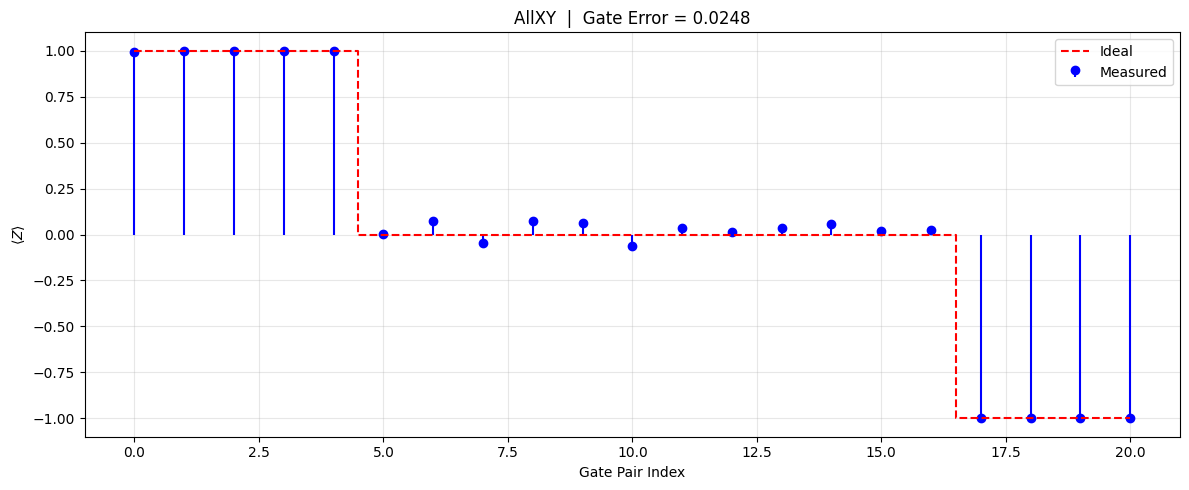

=== Calibration Summary ===
g_pi (ref_r180): nan
Primitive pulse amplitudes:
  x180 : 1.012507151587043
  y180 : None
  x90  : None
  xn90 : None
  y90  : None
  yn90 : None
Blob centers: mu_g=(-0.00015403432502457675+0.0001524198484562027j), mu_e=(0.0001063072429341467+0.00015202437016246937j)
Rotation angle: 1.2632407970331125
F=0.73646, Q=0.9704178296540642, V=0.4729199999999999
Confusion matrix:
[[0.74032, 0.2674], [0.25968, 0.7325999999999999]]
Transition matrix:
[[0.9944176604922609, 0.05358200118413254], [0.005582339507739094, 0.9464179988158674]]
ALLXY observable: sigma_z
ALLXY correction applied: True
ALLXY state mapping: {'g': 1.0, 'e': -1.0}
Final mapping: +1 -> |g>, -1 -> |e>
measureConfig persisted to: E:\qubox\seq_1_device\config\measureConfig.json


In [7]:
import importlib
from pathlib import Path
import qubox_v2.experiments.calibration.gates as gates_mod
importlib.reload(gates_mod)
from qubox_v2.experiments.calibration.gates import AllXY
from qubox_v2.programs.macros.measure import measureMacro

# Persist readout + pulse calibration artifacts for fresh-session reload
session.calibration.save()
session.save_pulses()
measure_cfg_path = Path(experiment_path) / "config" / "measureConfig.json"
measure_cfg_path.parent.mkdir(parents=True, exist_ok=True)
measureMacro.save_json(str(measure_cfg_path))

# Reload measureMacro from disk to validate persistence path
measureMacro.load_json(str(measure_cfg_path))

# Run ALLXY with corrected sigma_z scaling
allxy = AllXY(session)
allxy_result = allxy.run(n_avg=5000)
allxy_analysis = allxy.analyze(allxy_result)
allxy.plot(allxy_analysis)

cm = measureMacro._ro_quality_params.get("confusion_matrix", None)
tm = measureMacro._ro_quality_params.get("transition_matrix", None)

print("=== Calibration Summary ===")
print(f"g_pi (ref_r180): {float(globals().get('rabi_g_pi', float('nan'))):.6f}")

primitive_ops = ["x180", "y180", "x90", "xn90", "y90", "yn90"]
print("Primitive pulse amplitudes:")
for op_name in primitive_ops:
    pcal = session.calibration.get_pulse_calibration(op_name)
    print(f"  {op_name:5s}: {getattr(pcal, 'amplitude', None)}")

if "ro_pipeline_summary" in globals():
    disc = ro_pipeline_summary["discrimination"]
    bfly = ro_pipeline_summary["butterfly"]
    print(f"Blob centers: mu_g={disc.get('rot_mu_g')}, mu_e={disc.get('rot_mu_e')}")
    print(f"Rotation angle: {disc.get('angle')}")
    print(f"F={bfly.get('F')}, Q={bfly.get('Q')}, V={bfly.get('V')}")

print("Confusion matrix:")
print(cm)
print("Transition matrix:")
print(tm)
print(f"ALLXY observable: {allxy_analysis.metrics.get('observable')}")
print(f"ALLXY correction applied: {allxy_analysis.metrics.get('used_confusion_correction')}")
print(f"ALLXY state mapping: {allxy_analysis.metrics.get('state_mapping')}")
print("Final mapping: +1 -> |g>, -1 -> |e>")
print(f"measureConfig persisted to: {measure_cfg_path}")

## 7. SPA Benchmarking

### 7.1 SPA Flux Optimization

Sweep DC flux bias with SPA-enhanced readout to find optimal flux point.

In [ ]:
spa_flux = SPAFluxOptimization(session)
result = spa_flux.run(
    dc_list=np.linspace(-0.5, 0.5, 51),
    sample_fqs=np.linspace(8.5e9, 8.7e9, 21),
    n_avg=1000,
)

analysis = spa_flux.analyze(result)
spa_flux.plot(analysis)
print(f"Best DC = {analysis.metrics.get('best_dc', 'N/A'):.4f} V")
print(f"Best freq = {analysis.metrics.get('best_freq', 0) / 1e6:.2f} MHz")

### 7.2 SPA Pump Frequency Optimization

2D sweep of pump power and detuning to optimize SPA readout fidelity.

In [ ]:
spa_pump = SPAPumpFrequencyOptimization(session)
# result = spa_pump.run(
#     readout_op="readout",
#     drive_frequency=attr.qb_fq,
#     pump_powers=np.linspace(0.1, 1.0, 10),
#     pump_detunings=np.linspace(-5e6, 5e6, 21),
#     r180="x180",
#     samples_per_run=25000,
# )
# analysis = spa_pump.analyze(result)
# spa_pump.plot(analysis)
# print(f"Best pump power = {analysis.metrics.get('best_pump_power', 'N/A')}")
# print(f"Best pump detuning = {analysis.metrics.get('best_pump_detuning', 'N/A')}")

## 8. Storage Cavity

### 8.1 Storage Spectroscopy

Sweep storage cavity frequency to locate resonance.

In [ ]:
st_spec = StorageSpectroscopy(session)
result = st_spec.run(
    disp="const_alpha",
    rf_begin=5200 * u.MHz,
    rf_end=5280 * u.MHz,
    df=200 * u.kHz,
    storage_therm_time=500,
    n_avg=50,
)

analysis = st_spec.analyze(result, update_calibration=True)
st_spec.plot(analysis)
print(f"f_storage = {analysis.metrics['f_storage'] / 1e6:.4f} MHz")
print(f"kappa = {analysis.metrics['kappa'] / 1e3:.1f} kHz")

### 8.2 Number Splitting Spectroscopy

Resolve photon-number-dependent qubit frequency shifts.

`state_prep` is now explicit (not auto-generated). Define it in the notebook and pass it to `run()`.

In [ ]:
from qm.qua import wait

def prep_vacuum():
    # Explicit no-op preparation for notebook-driven workflows
    wait(1)

nsplit = NumSplittingSpectroscopy(session)
result = nsplit.run(
    rf_centers=[attr.qb_fq],
    rf_spans=[10 * u.MHz],
    df=100 * u.kHz,
    state_prep=prep_vacuum,
    n_avg=500,
    # Temporary backward-compat path if needed: allow_default_state_prep=True,
 )

analysis = nsplit.analyze(result)
nsplit.plot(analysis)
print(analysis.metrics)

### 8.3 Storage Chi Ramsey

Measure dispersive coupling chi via Ramsey interferometry.

In [ ]:
# NOTE: StorageChiRamsey requires measureMacro to be configured.
# Run CalibrateReadoutFull (Section 6) before this cell.

chi_ramsey = StorageChiRamsey(session)
result = chi_ramsey.run(
    fock_fq=attr.qb_fq,
    delay_ticks=np.arange(4, 2000, 10),
    disp_pulse="const_alpha",
    x90_pulse="x90",
    n_avg=20,
)

# p0: [P0, A, T2_eff(ns), nbar, chi(1/ns), t0(ns)]
# T2_eff ~ 35 us = 35000 ns;  chi ~ 2.8 MHz = 0.0028/ns;  t0 ~ 0.4 us = 400 ns
analysis = chi_ramsey.analyze(result, update_calibration=True,
                              p0=[0.5, 0.5, 35000, 0.1, 0.0028, 400])
chi_ramsey.plot(analysis)
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")
print(f"nbar = {analysis.metrics.get('nbar', 0):.2f}")

### 8.4 Fock-Resolved Spectroscopy

Probe qubit spectroscopy conditioned on Fock number.

In [ ]:
fock_spec = FockResolvedSpectroscopy(session)
result = fock_spec.run(
    probe_fqs=np.linspace(attr.qb_fq - 5e6, attr.qb_fq + 5e6, 101),
    state_prep=prep_vacuum,
    n_avg=20,
    # Temporary backward-compat path if needed: allow_default_state_prep=True,
 )

analysis = fock_spec.analyze(result)
fock_spec.plot(analysis)
print(analysis.metrics)

### 8.4b Register Displacement Pulses for Fock-Resolved Experiments

**REQUIRED** before running Fock-resolved T1, Ramsey, or Power Rabi.
This generates `disp_n0`, `disp_n1`, etc. on the storage element and burns them into the QM config.

In [ ]:
from qubox_v2.tools.generators import ensure_displacement_ops

# Number of Fock manifolds to prepare displacement pulses for
n_fock = 3

# Prefer session runtime settings (migrated ownership); fallback is handled in SessionManager
disp_ref = session.get_displacement_reference()
coherent_amp = disp_ref.get("coherent_amp", None)
coherent_len = disp_ref.get("coherent_len", None)
b_alpha = disp_ref.get("b_alpha", None)

# Generate displacement pulses using calibrated storage parameters
created = ensure_displacement_ops(
    session.pulse_mgr,
    element=attr.st_el,
    n_max=n_fock,
    coherent_amp=coherent_amp,
    coherent_len=coherent_len,
    b_alpha=b_alpha,
 )

# Burn into QM config so hardware programs can use them
session.burn_pulses()

print(f"Displacement refs: amp={coherent_amp}, len={coherent_len}, alpha={b_alpha}")
print(f"Registered {len(created)} displacement ops on '{attr.st_el}':")
for name, (I, Q) in created.items():
    print(f"  {name}: len={len(I)}, max_I={I.max():.4f}, max_Q={Q.max():.4f}")

### 8.5 Fock-Resolved T1

Measure T1 in individual Fock manifolds.

In [ ]:
fock_t1 = FockResolvedT1(session)

# fock_fqs defaults to attr.fock_fqs from cqed_params.json when not provided.
# To use a subset: fock_fqs = attr.get_fock_frequencies(2)
n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_t1.run(
     fock_fqs=fock_fqs,
     fock_disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=200,
     n_avg=20,
)
analysis = fock_t1.analyze(result)
fock_t1.plot(analysis)
for key, val in analysis.metrics.items():
     if key.startswith("T1_fock_"):
         print(f"{key} = {val / 1e3:.2f} us")

### 8.6 Fock-Resolved Ramsey

Measure T2 in individual Fock manifolds.

In [ ]:
fock_ramsey = FockResolvedRamsey(session)

# fock_fqs defaults to attr.fock_fqs from cqed_params.json when not provided.
n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_ramsey.run(
     fock_fqs=fock_fqs,
     detunings=[0.2e6],
     disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=100,
     n_avg=20,
)
analysis = fock_ramsey.analyze(result)
fock_ramsey.plot(analysis)
print(analysis.metrics)

### 8.7 Fock-Resolved Power Rabi

Calibrate selective pi pulses per Fock manifold.

In [ ]:
fock_rabi = FockResolvedPowerRabi(session)
# fock_fqs = [...]  # From NumSplittingSpectroscopy results
# result = fock_rabi.run(
#     fock_fqs=fock_fqs,
#     gains=np.linspace(0, 1.5, 50),
#     sel_qb_pulse="sel_x180",
#     disp_n_list=["disp_n0", "disp_n1", "disp_n2"],
#     n_avg=2000,
# )
# analysis = fock_rabi.analyze(result)
# fock_rabi.plot(analysis)
# for key, val in analysis.metrics.items():
#     if key.startswith("g_pi_fock_"):
#         print(f"{key} = {val:.4f}")

## 9. Quantum State Tomography

### 9.1 Qubit State Tomography

Three-axis measurement (sigma_x, sigma_y, sigma_z) to reconstruct
the qubit Bloch vector.

In [ ]:
from qm.qua import *

def prep_x_plus():
    """Prepare |+x> state."""
    play("x90", attr.qb_el)

tomo = QubitStateTomography(session)
result = tomo.run(
    state_prep=prep_x_plus,
    n_avg=10000,
)

analysis = tomo.analyze(result)
tomo.plot(analysis)
print(f"sx = {analysis.metrics.get('sx', 0):.3f}")
print(f"sy = {analysis.metrics.get('sy', 0):.3f}")
print(f"sz = {analysis.metrics.get('sz', 0):.3f}")
print(f"Purity = {analysis.metrics.get('purity', 0):.3f}")

### 9.2 Wigner Tomography

Reconstruct the Wigner function of the storage cavity state.

In [ ]:
wigner = StorageWignerTomography(session)
# Requires gate sequence for state preparation
# result = wigner.run(
#     gates=[...],
#     x_vals=np.linspace(-3, 3, 41),
#     p_vals=np.linspace(-3, 3, 41),
#     n_avg=500,
# )
# analysis = wigner.analyze(result)
# wigner.plot(analysis)
# print(f"W_min = {analysis.metrics.get('W_min', 0):.3f}")
# print(f"W_max = {analysis.metrics.get('W_max', 0):.3f}")
# print(f"Negativity = {analysis.metrics.get('negativity', 0):.3f}")

### 9.3 SNAP Optimization

Optimize SNAP gate angles using Fock-resolved state tomography.

In [ ]:
snap = SNAPOptimization(session)
# result = snap.run(
#     snap_gate=...,
#     disp1_gate=...,
#     fock_probe_fqs=[...],
#     n_avg=500,
# )
# analysis = snap.analyze(result)
# snap.plot(analysis)
# print(analysis.metrics)

## 9b. Session Verification & Summary

Run waveform regression checks, finalize session artifacts, and produce
a summary of all calibrations committed during this session.

### 9b.1 Waveform Regression Check

Verify that PulseFactory produces deterministic, correct waveforms for all
supported pulse shapes. Any failure here indicates a regression in the
waveform generation code.

In [ ]:
from qubox_v2.verification.waveform_regression import run_all_checks

wf_results = run_all_checks()
passed = sum(1 for r in wf_results if r.passed)
total = len(wf_results)
print(f"Waveform regression: {passed}/{total} passed")

for r in wf_results:
    if not r.passed:
        print(r)

if passed == total:
    print("All waveform regression checks PASSED.")
else:
    print(f"WARNING: {total - passed} waveform regression check(s) failed.")

### 9b.2 Session Summary & Artifact Finalization

Print build hash, all calibrations committed, key metrics, and save the
final session report via ArtifactManager.

In [ ]:
import datetime

print("=" * 60)
print("  SESSION SUMMARY")
print("=" * 60)
print(f"  Build hash:     {ss.build_hash}")
print(f"  Git commit:     {ss.git_commit or 'unknown'}")
print(f"  Timestamp:      {ss.build_timestamp}")
print()

# Collect calibration state machines
all_sms = []
for name in ["sm_rabi", "sm_drag", "sm_readout"]:
    try:
        sm_obj = eval(name)
        info = sm_obj.summary()
        all_sms.append(info)
        state_str = info["state"]
        committed = state_str == "committed"
        print(f"  {info['experiment']:20s}  {state_str:20s}  "
              f"{'COMMITTED' if committed else 'not committed'}")
    except NameError:
        pass

# Waveform regression
print(f"\n  Waveform regression:  {passed}/{total} passed")

# Schema validation
n_valid = sum(1 for r in schema_results if r.valid)
print(f"  Schema validation:    {n_valid}/{len(schema_results)} passed")

print()

# Save session summary report
report_lines = [
    f"# Session Report",
    f"",
    f"- Build hash: {ss.build_hash}",
    f"- Git commit: {ss.git_commit or 'unknown'}",
    f"- Timestamp:  {ss.build_timestamp}",
    f"- Report generated: {datetime.datetime.now().isoformat()}",
    f"",
    f"## Calibration State Machines",
    f"",
]
for info in all_sms:
    report_lines.append(f"- **{info['experiment']}**: {info['state']} "
                        f"({info['transitions']} transitions, "
                        f"has_patch={info['has_patch']})")
report_lines += [
    f"",
    f"## Verification",
    f"",
    f"- Waveform regression: {passed}/{total} passed",
    f"- Schema validation: {n_valid}/{len(schema_results)} passed",
]

am.save_report("session_summary", "\n".join(report_lines))

# List all artifacts
print("Artifacts:")
for artifact in am.list_artifacts():
    if artifact.is_file():
        print(f"  {artifact.relative_to(am.root)}")

print()
print("=" * 60)
from qubox_v2.core.artifact_manager import cleanup_artifacts
removed = cleanup_artifacts(experiment_path, keep_latest=5, current_hash=ss.build_hash)
if removed:
    print(f"  Cleaned up {len(removed)} old artifact directories.")
print("  Done.")

## 10. Utility: Continuous-Wave Output

Drive a target element continuously (infinite loop) for diagnostics such as
spectrum analyser alignment or mixer leakage checks. The program runs
indefinitely until manually halted via `job.halt()`.

In [ ]:
from qubox_v2.programs import cQED_programs

# --- CW parameters ---
target_element = attr.qb_el       # element to drive
cw_pulse = "const_x180"           # pulse operation to repeat
cw_gain = 0.5                     # amplitude scaling (0.0 to 1.0)
truncate_clks = 250               # truncate pulse length in clock cycles (1 clk = 4 ns)

# --- Build the infinite-loop program ---
cw_prog = cQED_programs.continuous_wave(
    target_el=target_element,
    pulse=cw_pulse,
    gain=cw_gain,
    truncate_clks=truncate_clks,
)

print(f"Starting CW output on '{target_element}'")
print(f"  pulse      = {cw_pulse}")
print(f"  gain       = {cw_gain}")
print(f"  truncate   = {truncate_clks} clks ({truncate_clks * 4} ns)")
print(f"  This program runs in an INFINITE LOOP.")
print(f"  To stop:  job.halt()")

# Execute directly on the quantum machine
job = session.hw.qm.execute(cw_prog)
print(f"\nJob started: {job.id}")
print("Run 'job.halt()' in the next cell to stop.")

In [ ]:
# --- Stop CW output ---
job.halt()
print("CW output halted.")

---

## Summary

All experiment classes follow the unified `run() -> analyze() -> plot()` protocol:

```python
exp = ExperimentClass(session)
result = exp.run(...)                              # Execute on hardware
analysis = exp.analyze(result, update_calibration=True)  # Fit + extract metrics
exp.plot(analysis)                                 # Visualize
print(analysis.metrics)                            # Inspect extracted parameters
```

Use `update_calibration=True` to automatically persist calibration results
to the `CalibrationStore`.

### Declarative Architecture Integration

This notebook integrates the **qubox_v2 declarative architecture** at key workflow points:

| Component | Where | Purpose |
|---|---|---|
| `SessionState` | Section 1.0b | Immutable config snapshot with SHA-256 build hash |
| `validate_config_dir` | Section 1.1 | Schema validation of all config files |
| `ArtifactManager` | Section 1.0b | Build-hash keyed artifact storage |
| `CalibrationStateMachine` | Sections 5.1b, 6.4 | Lifecycle enforcement for calibration commits |
| `CalibrationPatch` | Sections 5.1b, 6.4 | Explicit diff objects with quality gates |
| `run_all_checks` | Section 9b.1 | Waveform regression verification |

Every calibration commit is tracked through a state machine lifecycle
(`IDLE -> CONFIGURED -> ACQUIRING -> ACQUIRED -> ANALYZING -> ANALYZED -> PENDING_APPROVAL -> COMMITTED`)
with explicit patches, validation gates, and artifact persistence for full audit trail.

### Storage Spectroscopy (Orchestrator Pipeline)

Run storage mode spectroscopy via the Artifact → CalibrationResult → Patch → Orchestrator flow.

In [ ]:
st_spec = StorageSpectroscopy(session)
st_center = float(getattr(attr, "st_fq", attr.qb_fq))
st_cycle = orch.run_analysis_patch_cycle(
    st_spec,
    run_kwargs={
        "disp": "const_alpha",
        "rf_begin": (st_center - 5 * u.MHz),
        "rf_end": (st_center + 5 * u.MHz),
        "df": 200 * u.kHz,
        "storage_therm_time": int(getattr(attr, "qb_therm_clks", 0)),
        "sel_r180": "sel_x180",
        "n_avg": 1000,
    },
    analyze_kwargs={"update_calibration": True},
    apply=False,
    persist_artifact=True,
 )

st_result = orch._run_result_from_artifact(st_cycle["artifact"])
st_analysis = st_spec.analyze(st_result, update_calibration=False)
st_spec.plot(st_analysis)
print(f"storage f0 = {st_cycle['calibration_result'].params.get('f_storage_MHz', float('nan')):.4f} MHz")
print("Patch preview:")
for item in st_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(st_cycle["patch"], dry_run=False)